In [1]:
# ============================================================
# Assignment Part 4: Data Visualization & Machine Learning
# Theme: Student Performance Analysis & Prediction
# ============================================================

import pandas as pd                          # data handling library
import matplotlib.pyplot as plt              # plotting library
import seaborn as sns                        # high-level plotting library
from sklearn.model_selection import train_test_split   # splits data into train/test
from sklearn.preprocessing import StandardScaler       # normalises feature values
from sklearn.linear_model import LogisticRegression    # classification model
from sklearn.metrics import accuracy_score             # measures how accurate the model is

# students.csv data
csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""
with open("students.csv", "w") as f:
    f.write(csv_content)
# ==============================================================
# TASK 1 — Data Exploration with Pandas
# ==============================================================

print("*" * 50)
print("TASK 1 — Data Exploration with Pandas")
print("*" * 50)

df = pd.read_csv("students.csv")

# 1. First 5 rows
print("\n--- First 5 rows (.head()) ---")
print(df.head())

# 2. Shape and data types
print(f"\n--- Shape: {df.shape[0]} rows × {df.shape[1]} columns ---")
print("\n--- Data types (.dtypes) ---")
print(df.dtypes)

# 3. Summary statistics
print("\n--- Summary statistics (.describe()) ---")
print(df.describe())

# 4. Pass/Fail count
print("\n--- Pass/Fail count ---")
print(df['passed'].value_counts())

# 5. Average score per subject for passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# .mean() calculates the average of each column
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\n--- Average scores: Passing students ---")
print(pass_avg.round(2))

print("\n--- Average scores: Failing students ---")
print(fail_avg.round(2))

# 6. Student with highest overall average
temp_avg = df[subject_cols].mean(axis=1)

top_idx = temp_avg.idxmax()
top_student = df.loc[top_idx, 'name']
top_average = round(temp_avg[top_idx], 2)

print(f"\n--- Top student: {top_student} with average {top_average} ---")



**************************************************
TASK 1 — Data Exploration with Pandas
**************************************************

--- First 5 rows (.head()) ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Shape: 15 rows × 9 columns ---

--- Data types (.dtypes) ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe    


**************************************************
TASK 2 — Data Visualization (Matplotlib)
**************************************************


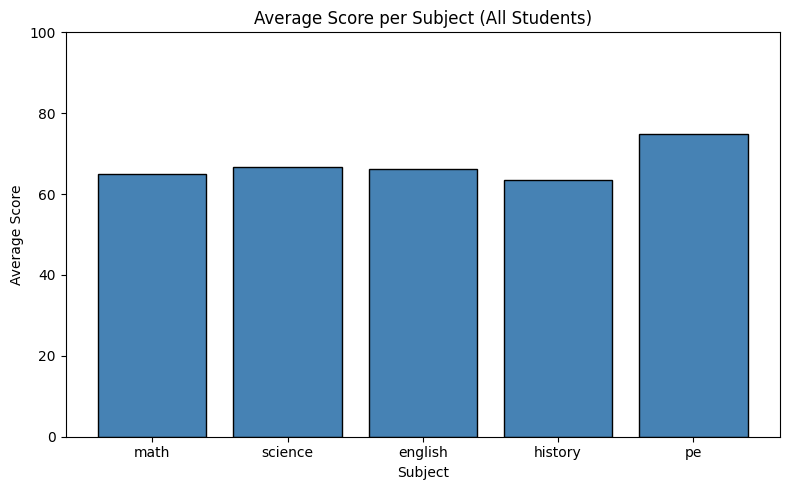

✓ Saved plot1_bar.png


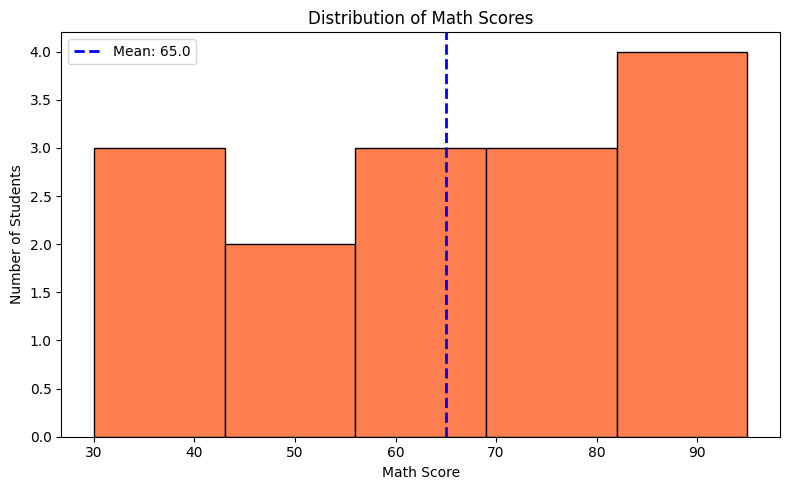

✓ Saved plot2_histogram.png


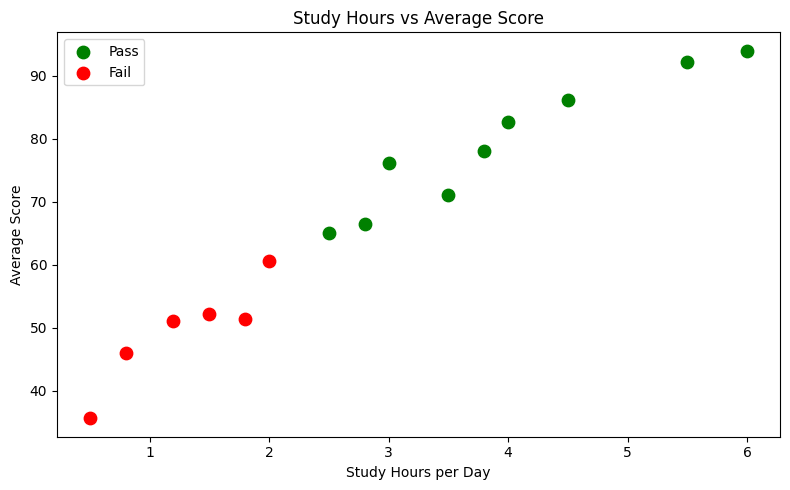

✓ Saved plot3_scatter.png


/tmp/ipykernel_13688/1464020843.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


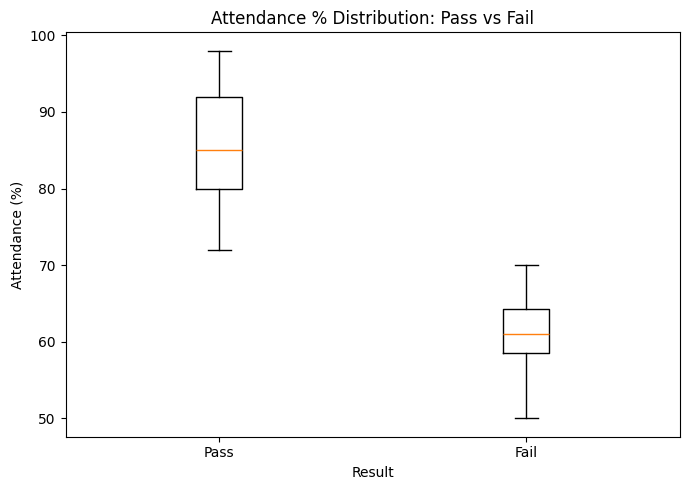

✓ Saved plot4_boxplot.png


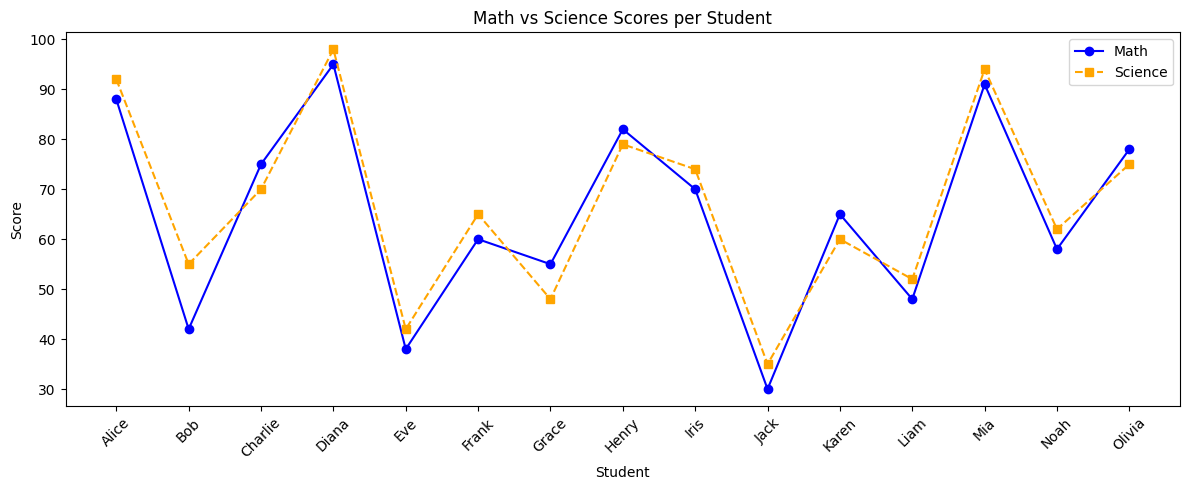

✓ Saved plot5_line.png


In [2]:

# ==============================================================
# TASK 2 — Data Visualization with Matplotlib
# ==============================================================

print("\n" + "*" * 50)
print("TASK 2 — Data Visualization (Matplotlib)")
print("*" * 50)

df['avg_score'] = df[subject_cols].mean(axis=1)

# ---- Plot 1: Bar Chart — Average score per subject ----
subject_averages = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_averages.index, subject_averages.values, color='steelblue', edgecolor='black')
plt.title("Average Score per Subject (All Students)")   # chart title
plt.xlabel("Subject")                                   # x-axis label
plt.ylabel("Average Score")                             # y-axis label
plt.ylim(0, 100)                                        # y-axis range
plt.tight_layout()                                      # prevents labels from being cut off
plt.savefig("plot1_bar.png")                            # save as PNG file
plt.show()                                              # display it
print("✓ Saved plot1_bar.png")

# ---- Plot 2: Histogram — Distribution of math scores ----
mean_math = df['math'].mean()

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.axvline(mean_math, color='blue', linestyle='--', linewidth=2, label=f"Mean: {mean_math:.1f}")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()
print("✓ Saved plot2_histogram.png")

# ---- Plot 3: Scatter Plot — study hours vs avg_score, coloured by pass/fail ----

pass_df = df[df['passed'] == 1]   # filter: only passing students
fail_df = df[df['passed'] == 0]   # filter: only failing students

plt.figure(figsize=(8, 5))

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass', s=80)
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red',   label='Fail', s=80)
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()
print("✓ Saved plot3_scatter.png")

# ---- Plot 4: Box Plot — attendance distribution for pass vs fail ----

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()  # .tolist() converts Series to plain list
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(7, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance % Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")
plt.tight_layout()
plt.savefig("plot4_boxplot.png")
plt.show()
print("✓ Saved plot4_boxplot.png")

# ---- Plot 5: Line Plot — math and science scores per student ----
student_names = df['name'].tolist()

plt.figure(figsize=(12, 5))

plt.plot(student_names, df['math'],    marker='o', linestyle='-',  label='Math',    color='blue')
plt.plot(student_names, df['science'], marker='s', linestyle='--', label='Science', color='orange')
plt.title("Math vs Science Scores per Student")
plt.xlabel("Student")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()
print("✓ Saved plot5_line.png")



**************************************************
TASK 3 — Data Visualization (Seaborn)
**************************************************


/tmp/ipykernel_13688/1216295030.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math',    ax=ax1, palette='Set2')
/tmp/ipykernel_13688/1216295030.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')


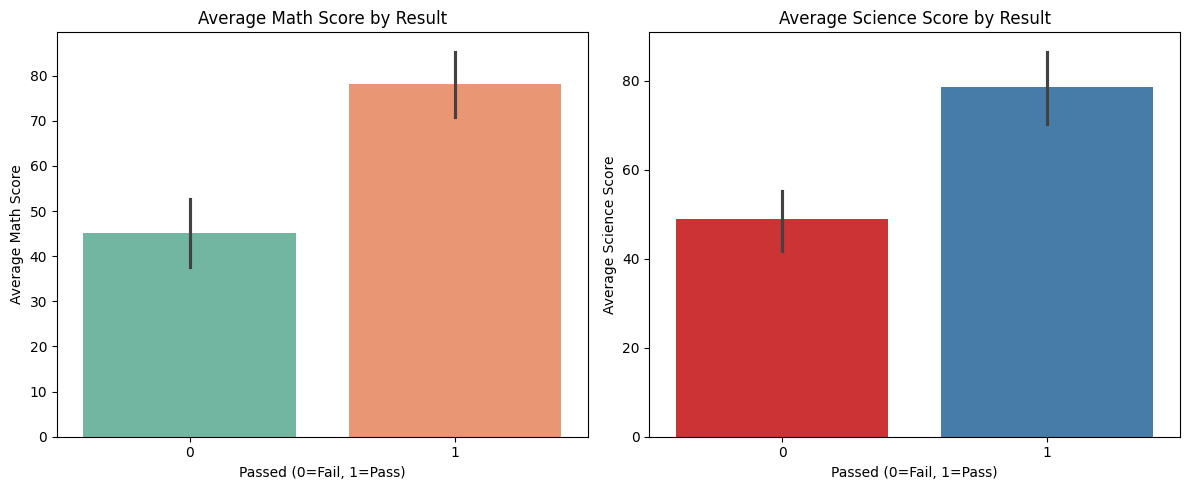

✓ Saved plot6_seaborn_bar.png


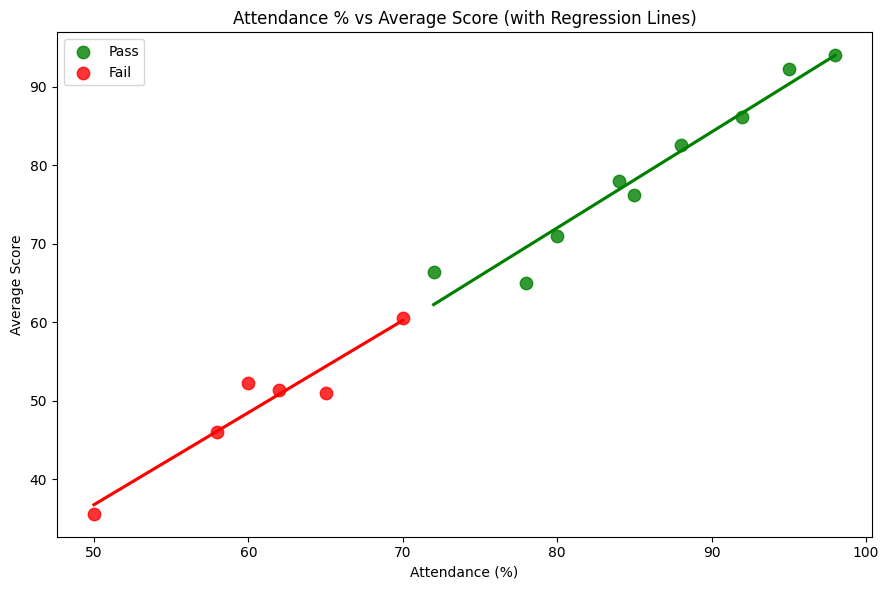

✓ Saved plot7_seaborn_scatter.png


In [3]:


# ==============================================================
# TASK 3 — Data Visualization with Seaborn
# ==============================================================

print("\n" + "*" * 50)
print("TASK 3 — Data Visualization (Seaborn)")
print("*" * 50)

# ---- Seaborn Plot 1: Bar plots for math and science, split by pass/fail ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# x='passed' → x-axis is 0 or 1 (Fail/Pass)
# y='math'   → y-axis shows average math scores
# ax=ax1     → draw this on the left subplot
sns.barplot(data=df, x='passed', y='math',    ax=ax1, palette='Set2')
ax1.set_title("Average Math Score by Result")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Average Math Score")

sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')
ax2.set_title("Average Science Score by Result")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Average Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()
print("✓ Saved plot6_seaborn_bar.png")

# ---- Seaborn Plot 2: Scatter + regression lines for attendance vs avg_score ----
plt.figure(figsize=(9, 6))

sns.regplot(data=pass_df, x='attendance_pct', y='avg_score', label='Pass', color='green', ci=None,
            scatter_kws={'s': 80})
sns.regplot(data=fail_df, x='attendance_pct', y='avg_score', label='Fail', color='red',   ci=None,
            scatter_kws={'s': 80})

plt.title("Attendance % vs Average Score (with Regression Lines)")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()
print("✓ Saved plot7_seaborn_scatter.png")

# Seaborn vs Matplotlib comparison:
# - Seaborn was easier for statistical plots like bar charts with group comparisons —
#   sns.barplot() automatically calculates means and adds error bars in one line.



**************************************************
TASK 4 — Machine Learning with scikit-learn
**************************************************

Training samples: 12, Test samples: 3

Training Accuracy: 100.0%
Test Accuracy: 100.0%

--- Per-student predictions ---
  Jack            | Actual: Fail | Predicted: Fail | ✅
  Liam            | Actual: Fail | Predicted: Fail | ✅
  Alice           | Actual: Pass | Predicted: Pass | ✅

--- Feature Coefficients (most influential first) ---
  english                   : +0.8125  → Pass
  attendance_pct            : +0.5219  → Pass
  study_hours_per_day       : +0.4844  → Pass
  pe                        : +0.4750  → Pass
  math                      : +0.4379  → Pass
  science                   : +0.3230  → Pass
  history                   : +0.2629  → Pass


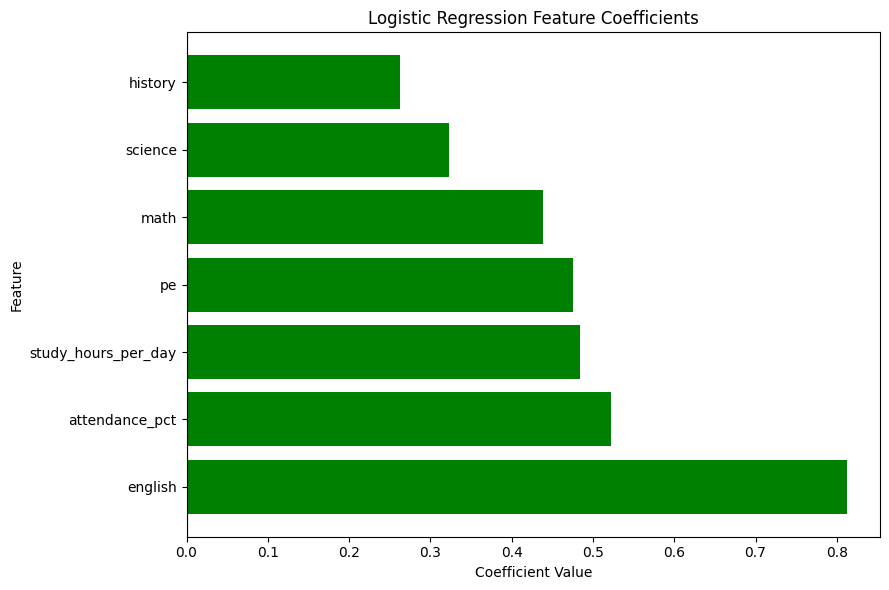

✓ Saved plot8_coefficients.png

--- BONUS: Predict for a new student ---
  New student prediction: Pass ✅
  Probability of Fail: 9.2%
  Probability of Pass: 90.8%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:


# ==============================================================
# TASK 4 — Machine Learning with scikit-learn
# ==============================================================

print("\n" + "*" * 50)
print("TASK 4 — Machine Learning with scikit-learn")
print("*" * 50)

# ---- Step 1: Prepare Data ----

feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
# Target (y) = what we want to predict
y = df['passed']

# test_size=0.2 means 20% of data goes to testing, 80% for training
# random_state=42 makes the split reproducible (same split every time)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")


scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

# ---- Step 2: Train the Model ----

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)   # .fit() = train the model

# Training accuracy
train_preds     = model.predict(X_train_scaled)
train_accuracy  = accuracy_score(y_train, train_preds)
print(f"\nTraining Accuracy: {train_accuracy * 100:.1f}%")

# ---- Step 3: Evaluate the Model ----
test_preds = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_accuracy * 100:.1f}%")

# Show each test student's prediction vs actual result
print("\n--- Per-student predictions ---")
# df.loc[indices, 'name'] lets us look up the names for those rows
test_names = df.loc[X_test.index, 'name'].tolist()

for name, actual, predicted in zip(test_names, y_test, test_preds):
    actual_label    = "Pass" if actual    == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    correct         = "✅" if actual == predicted else "❌"
    print(f"  {name:<15} | Actual: {actual_label:<4} | Predicted: {predicted_label:<4} | {correct}")

# ---- Step 4: Feature Importance ----


coefficients = model.coef_[0]

feature_importance = list(zip(feature_cols, coefficients))


feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Coefficients (most influential first) ---")
for feature, coeff in feature_importance:
    direction = "→ Pass" if coeff > 0 else "→ Fail"
    print(f"  {feature:<25} : {coeff:+.4f}  {direction}")


features_sorted = [f for f, _ in feature_importance]
coeffs_sorted   = [c for _, c in feature_importance]


colours = ['green' if c > 0 else 'red' for c in coeffs_sorted]

plt.figure(figsize=(9, 6))
plt.barh(features_sorted, coeffs_sorted, color=colours)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_coefficients.png")
plt.show()
print("✓ Saved plot8_coefficients.png")

# ---- Step 5 (Bonus): Predict for a New Student ----
print("\n--- BONUS: Predict for a new student ---")

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_student_scaled = scaler.transform(new_student)

prediction    = model.predict(new_student_scaled)[0]
probabilities = model.predict_proba(new_student_scaled)[0]

result = "Pass ✅" if prediction == 1 else "Fail ❌"
print(f"  New student prediction: {result}")
print(f"  Probability of Fail: {probabilities[0]*100:.1f}%")
print(f"  Probability of Pass: {probabilities[1]*100:.1f}%")